In [1]:
%load_ext watermark
%watermark -v -n -m -p numpy,scipy,sklearn,pandas
# suppress warnings

import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

# reload all modules every time before executing the Python code
%load_ext autoreload 
%autoreload 2
%matplotlib inline
import os
import sys

print(f'default sys.path: {sys.path}')
# Probably not needed for pycharm but needed for vscode -----------------------------------
PROJ_ROOT = os.path.abspath(os.path.join(os.pardir))
PROJ_ROOT = os.path.abspath(os.path.join(PROJ_ROOT, os.pardir))
sys.path.append(PROJ_ROOT)
print(f'Project root: {PROJ_ROOT}')
# Probably not needed for pycharm but needed for vscode -----------------------------------

from utils import mpl_settings
import pandas as pd
from scipy.stats import stats
import pymannkendall as mk
import seaborn as sns
import ast
import numpy as np
from nltk.util import ngrams
from collections import Counter



mpl_settings.apply_settings()

Python implementation: CPython
Python version       : 3.10.14
IPython version      : 8.20.0

numpy  : 1.26.4
scipy  : 1.11.4
sklearn: 1.3.0
pandas : 2.2.1

Compiler    : GCC 11.2.0
OS          : Linux
Release     : 6.1.0-25-amd64
Machine     : x86_64
Processor   : 
CPU cores   : 16
Architecture: 64bit

default sys.path: ['/home/steph/Documents/code_projects/Political-Advertising-2022-AU-Federal-Election/src/notebooks', '/home/steph/miniconda3/envs/fbads/lib/python310.zip', '/home/steph/miniconda3/envs/fbads/lib/python3.10', '/home/steph/miniconda3/envs/fbads/lib/python3.10/lib-dynload', '', '/home/steph/miniconda3/envs/fbads/lib/python3.10/site-packages']
Project root: /home/steph/Documents/code_projects/Political-Advertising-2022-AU-Federal-Election


In [2]:
from utils.dataset_utilities import load_data

file_path = '../../data/processed/2022_aus_elections_mar_to_may.csv'

df = load_data(file_path)

df.shape

[nltk_data] Downloading package stopwords to /home/steph/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /home/steph/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /home/steph/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


(56224, 43)

In [3]:
# throw away rows where multiword_safe_lemmatized is empty
df = df[df['multiword_safe_lemmatized'].notna()]

In [4]:
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from collections import defaultdict
import nltk

# Download required NLTK data
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)

def get_cooccurring_words(df, seed):
    # Initialize WordNetLemmatizer
    lemmatizer = WordNetLemmatizer()
    
    # Lemmatize the seed word
    lemmatized_seed = lemmatizer.lemmatize(seed.lower())
    
    # Initialize defaultdicts to store word occurrences
    word_ads = defaultdict(set)
    seed_ads = set()
    
    # Iterate through each row in the dataframe
    for idx, text in df['multiword_safe_lemmatized'].items():
        # Since the text is already lemmatized, we just need to tokenize and lowercase
        words = set(word.lower() for word in word_tokenize(text))
        
        # If the lemmatized seed is in the words, add this ad to seed_ads
        if lemmatized_seed in words:
            seed_ads.add(idx)
        
        # Add this ad to the set for each word
        for word in words:
            if word != lemmatized_seed:
                word_ads[word].add(idx)
    
    # Calculate Jaccard scores
    jaccard_scores = {}
    for word, ads in word_ads.items():
        intersection = len(seed_ads.intersection(ads))
        union = len(seed_ads.union(ads))
        jaccard_scores[word] = intersection / union if union > 0 else 0
    
    # Sort words by Jaccard score
    sorted_scores = sorted(jaccard_scores.items(), key=lambda x: x[1], reverse=True)
    
    return sorted_scores

In [5]:
cooccurring = get_cooccurring_words(df, 'election')
print(cooccurring[:15]) 

[('vote', 0.1867725973935466), ('party', 0.1677138714354761), ('click', 0.16375872382851445), ('better', 0.1579683898584129), ('candidate', 0.15333534560821008), ('heard', 0.15183374083129583), ('demand', 0.14831230821684283), ('may', 0.10286734352337387), ('australian', 0.10167191066691345), ('australia', 0.09892511221356012), ('day', 0.09799414960300877), ('need', 0.09792284866468842), ('people', 0.09579675238909176), ('liberal', 0.09560313684025024), ('u', 0.09026736080472955)]


The set of keywords was already selected by us so here we just import it

In [48]:
# load keywords from csv into a list from '../../data/external/keywords.csv'
keywords = pd.read_csv('../../data/external/keywords.csv', header=None)
keywords = keywords[0].tolist()
len(keywords)

43

In [49]:
from nltk.stem import PorterStemmer
keywords_map = {}
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()
stemmed_keywords = set([stemmer.stem(word) for word in keywords])

for kwd in keywords:
    keywords_map[stemmer.stem(kwd)] = kwd

#keywords = set([lemmatizer.lemmatize(word) for word in keywords])

keywords_pattern = '|'.join([f'(?i){word}' for word in stemmed_keywords])

In [50]:
# Add new columns with True or False values
df['has_political_keywords'] = df['stemmed_body'].str.contains(keywords_pattern, regex=True, na=False)

In [51]:
df_keywords = df[(df['has_political_keywords'] == True)]

df_keywords_noparty = df[(df['has_political_keywords'] == True) & (df['party'].isna())]

df_keywords_party = df[(df['has_political_keywords'] == True) & (df['party'].notna())]

In [52]:
df_keywords.shape

(47503, 43)

In [53]:
 # Count ads kept by each method
party_ads = df['has_party'].sum()
# Count ads kept by both methods (overlap)
overlap_ads = df[df['has_party'] & df['has_political_keywords']].shape[0]
print(f"\n{'Percentage of party ads that have a keyword:':<40} {overlap_ads / party_ads:.4f}")


Percentage of party ads that have a keyword: 0.9307


# Plotting

In [54]:
# Count occurrences of each keyword
keyword_counts = {keyword: df_keywords['stemmed_body'].str.contains(keyword, case=False, na=False).sum() for keyword in stemmed_keywords}
# sort the dictionary by values
keyword_counts = dict(sorted(keyword_counts.items(), key=lambda item: item[1], reverse=True))
# merge the counters for labor and labour
keyword_counts['labor'] += keyword_counts['labour']
keyword_counts['labour'] = 0

# eliminate words with count 0
keyword_counts = {k: v for k, v in keyword_counts.items() if v > 0}

keyword_counts

{'elect': 12774,
 'govern': 12338,
 'vote': 11170,
 'labor': 10772,
 'plan': 9948,
 'futur': 8841,
 'commun': 7585,
 'feder': 7335,
 'local': 6870,
 'chang': 6583,
 'morrison': 6462,
 'parti': 6289,
 'climat': 5845,
 'liber': 5507,
 'candid': 4381,
 'green': 4147,
 'scott': 3830,
 'nation': 3810,
 'cut': 2727,
 'author': 2534,
 'albanes': 2361,
 'polici': 2246,
 'parliament': 2017,
 'environ': 2003,
 'senat': 1912,
 'planet': 1567,
 'announc': 1392,
 'anthoni': 1210,
 'democrat': 873,
 'humphrey': 490,
 'adam': 108,
 'economicrecoveri': 79,
 'buildingindustri': 78,
 'strongbuild': 78,
 'federalelections2022': 78,
 'constructionindustri': 78,
 'yfs2022': 74,
 'youngpeoplematt': 62,
 'howard': 60,
 'bandt': 54,
 'anderson': 40,
 'animaljusticeparti': 20}

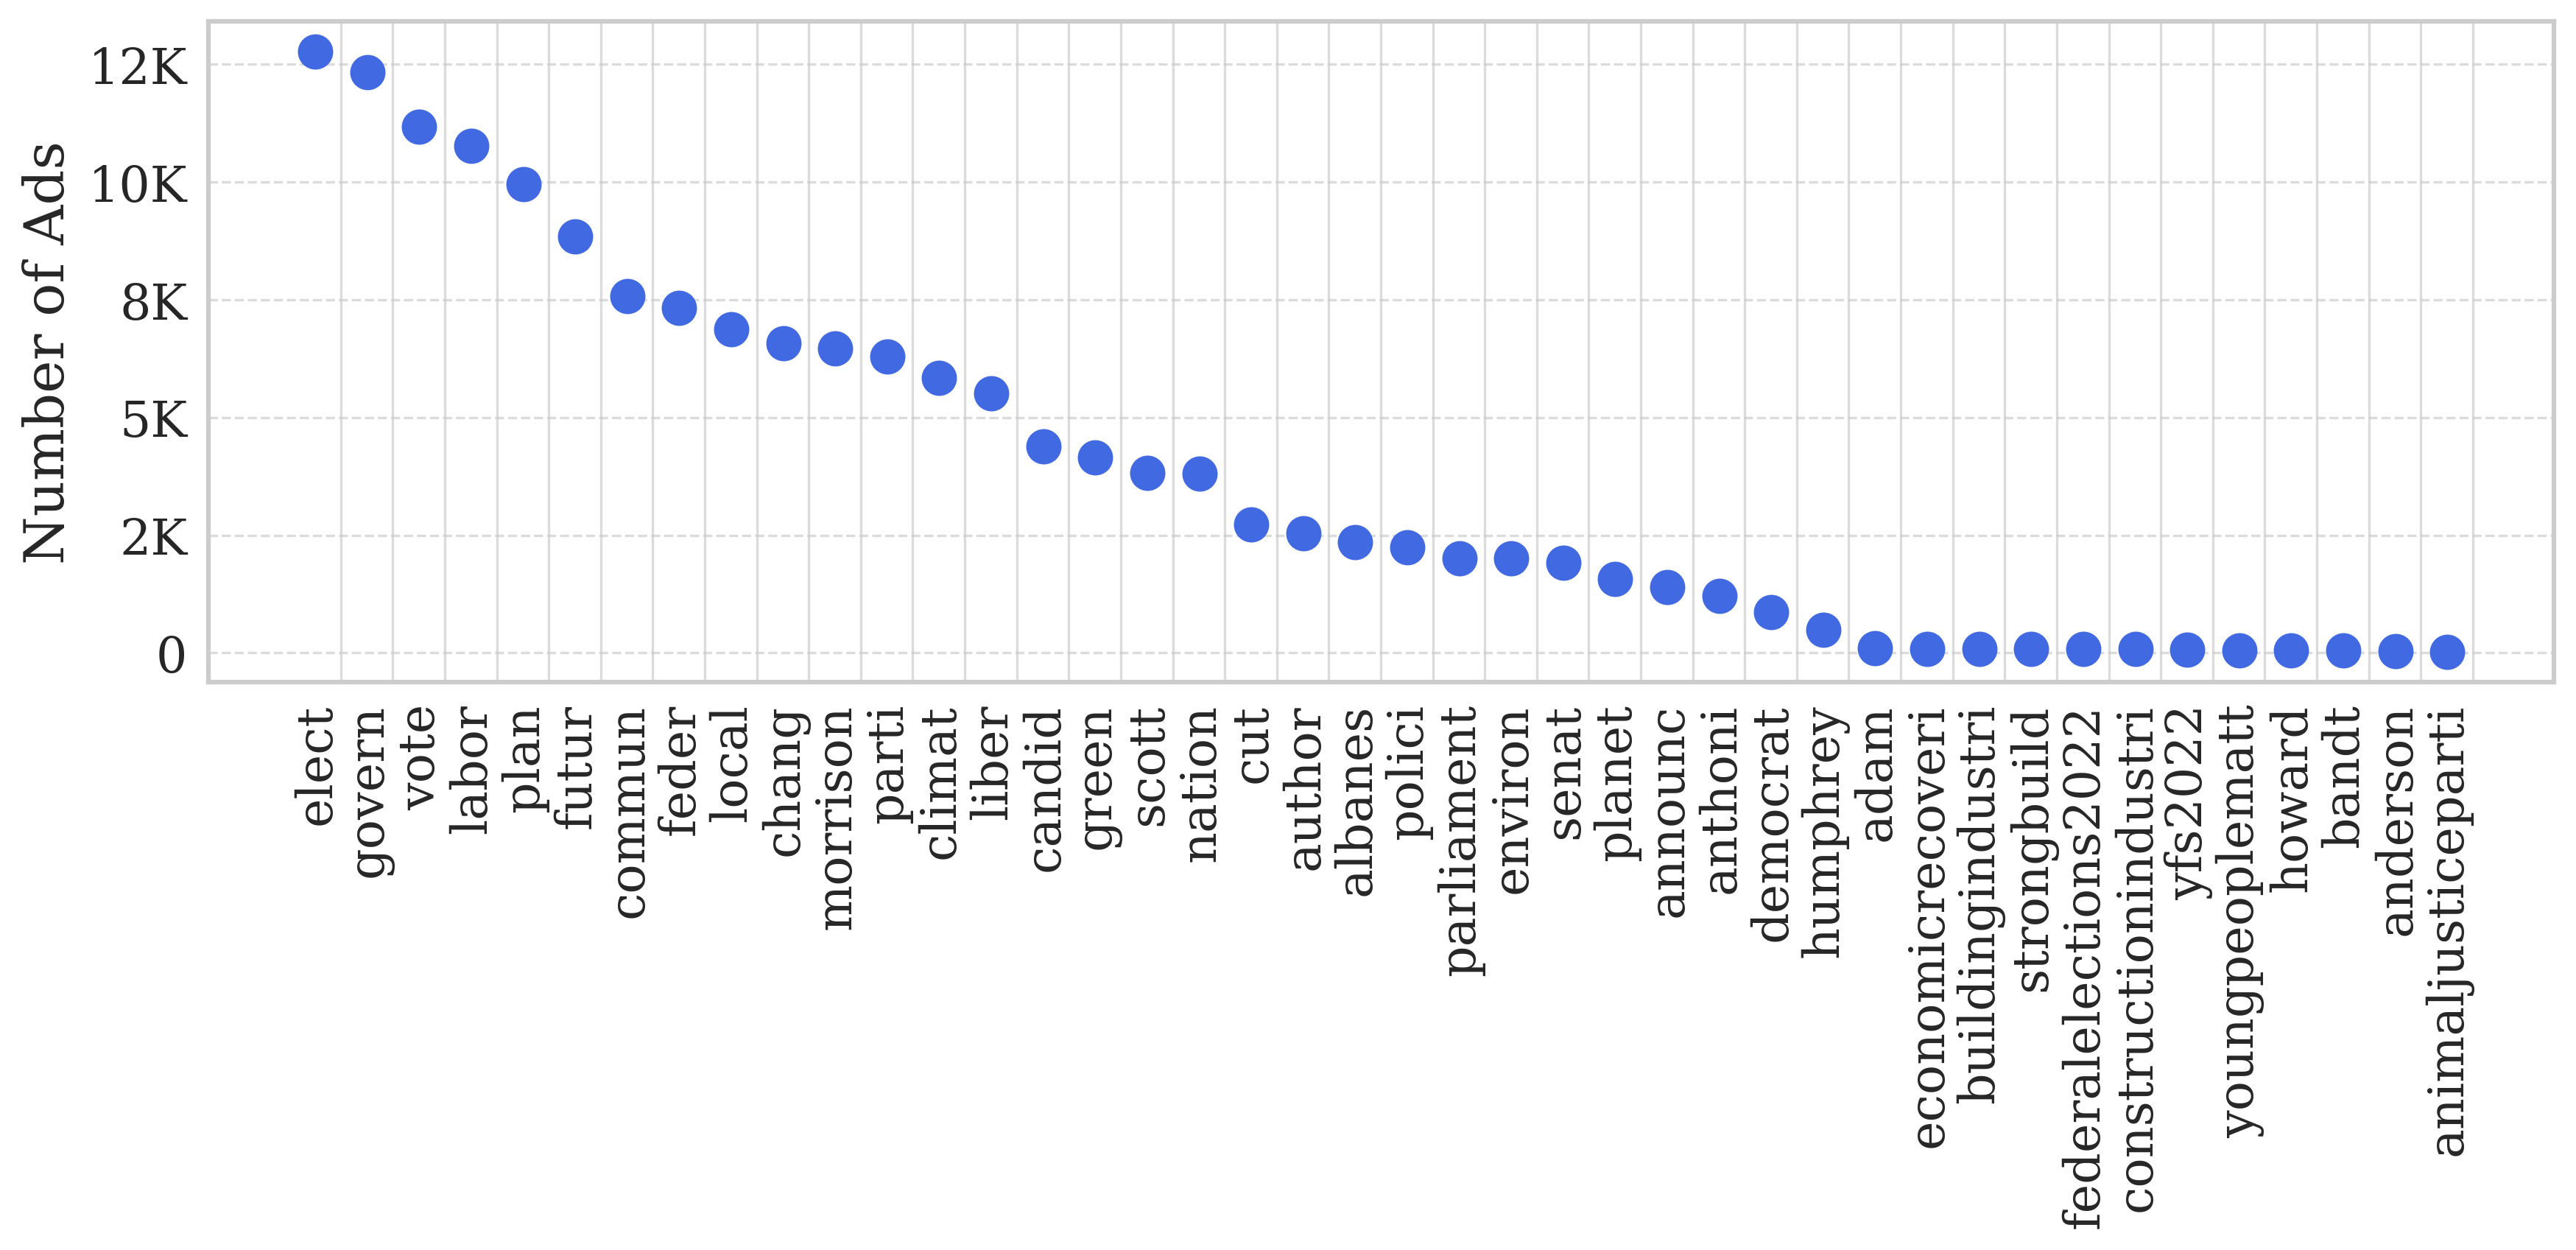

In [55]:

def create_keyword_dot_plot(keyword_counts, 
                            figsize=(12, 6),
                            dot_size=100,
                            dot_color='royalblue',
                            axis_label_size=18,
                            tick_label_size=16,
                            ylabel='Number of Ads',
                            grid=False,
                            xtick_offset=0.49):
                            
    def thousands_formatter(x, pos):
        return f'{x/1000:.0f}K' if x >= 1000 else f'{x:.0f}'

    
    # Sort the keyword counts
    sorted_keywords = sorted(keyword_counts.items(), key=lambda x: x[1], reverse=True)
    keywords, counts = zip(*sorted_keywords)
    
    # Create the plot
    plt.figure(figsize=figsize)
    
    # Use range for x-coordinates to align dots with labels
    x = range(len(keywords))
    plt.scatter(x, counts, s=dot_size, color=dot_color, linewidth=1.5)
    
    # Set x-ticks and labels
    plt.xticks([i + xtick_offset for i in x], keywords, rotation=90, ha='right')
    
    # Set labels and title
    plt.ylabel(ylabel, fontsize=axis_label_size)
    
    # Customize ticks
    plt.tick_params(axis='both', which='major', labelsize=tick_label_size)
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(thousands_formatter))
    
    # Add grid if specified
    plt.grid(grid, axis='y', linestyle='--', alpha=0.7)
    plt.grid(grid, axis='x', alpha=0.7)
    
    # Improve overall appearance
    plt.tight_layout()
    
    return plt

plt = create_keyword_dot_plot(keyword_counts)
plt.show()

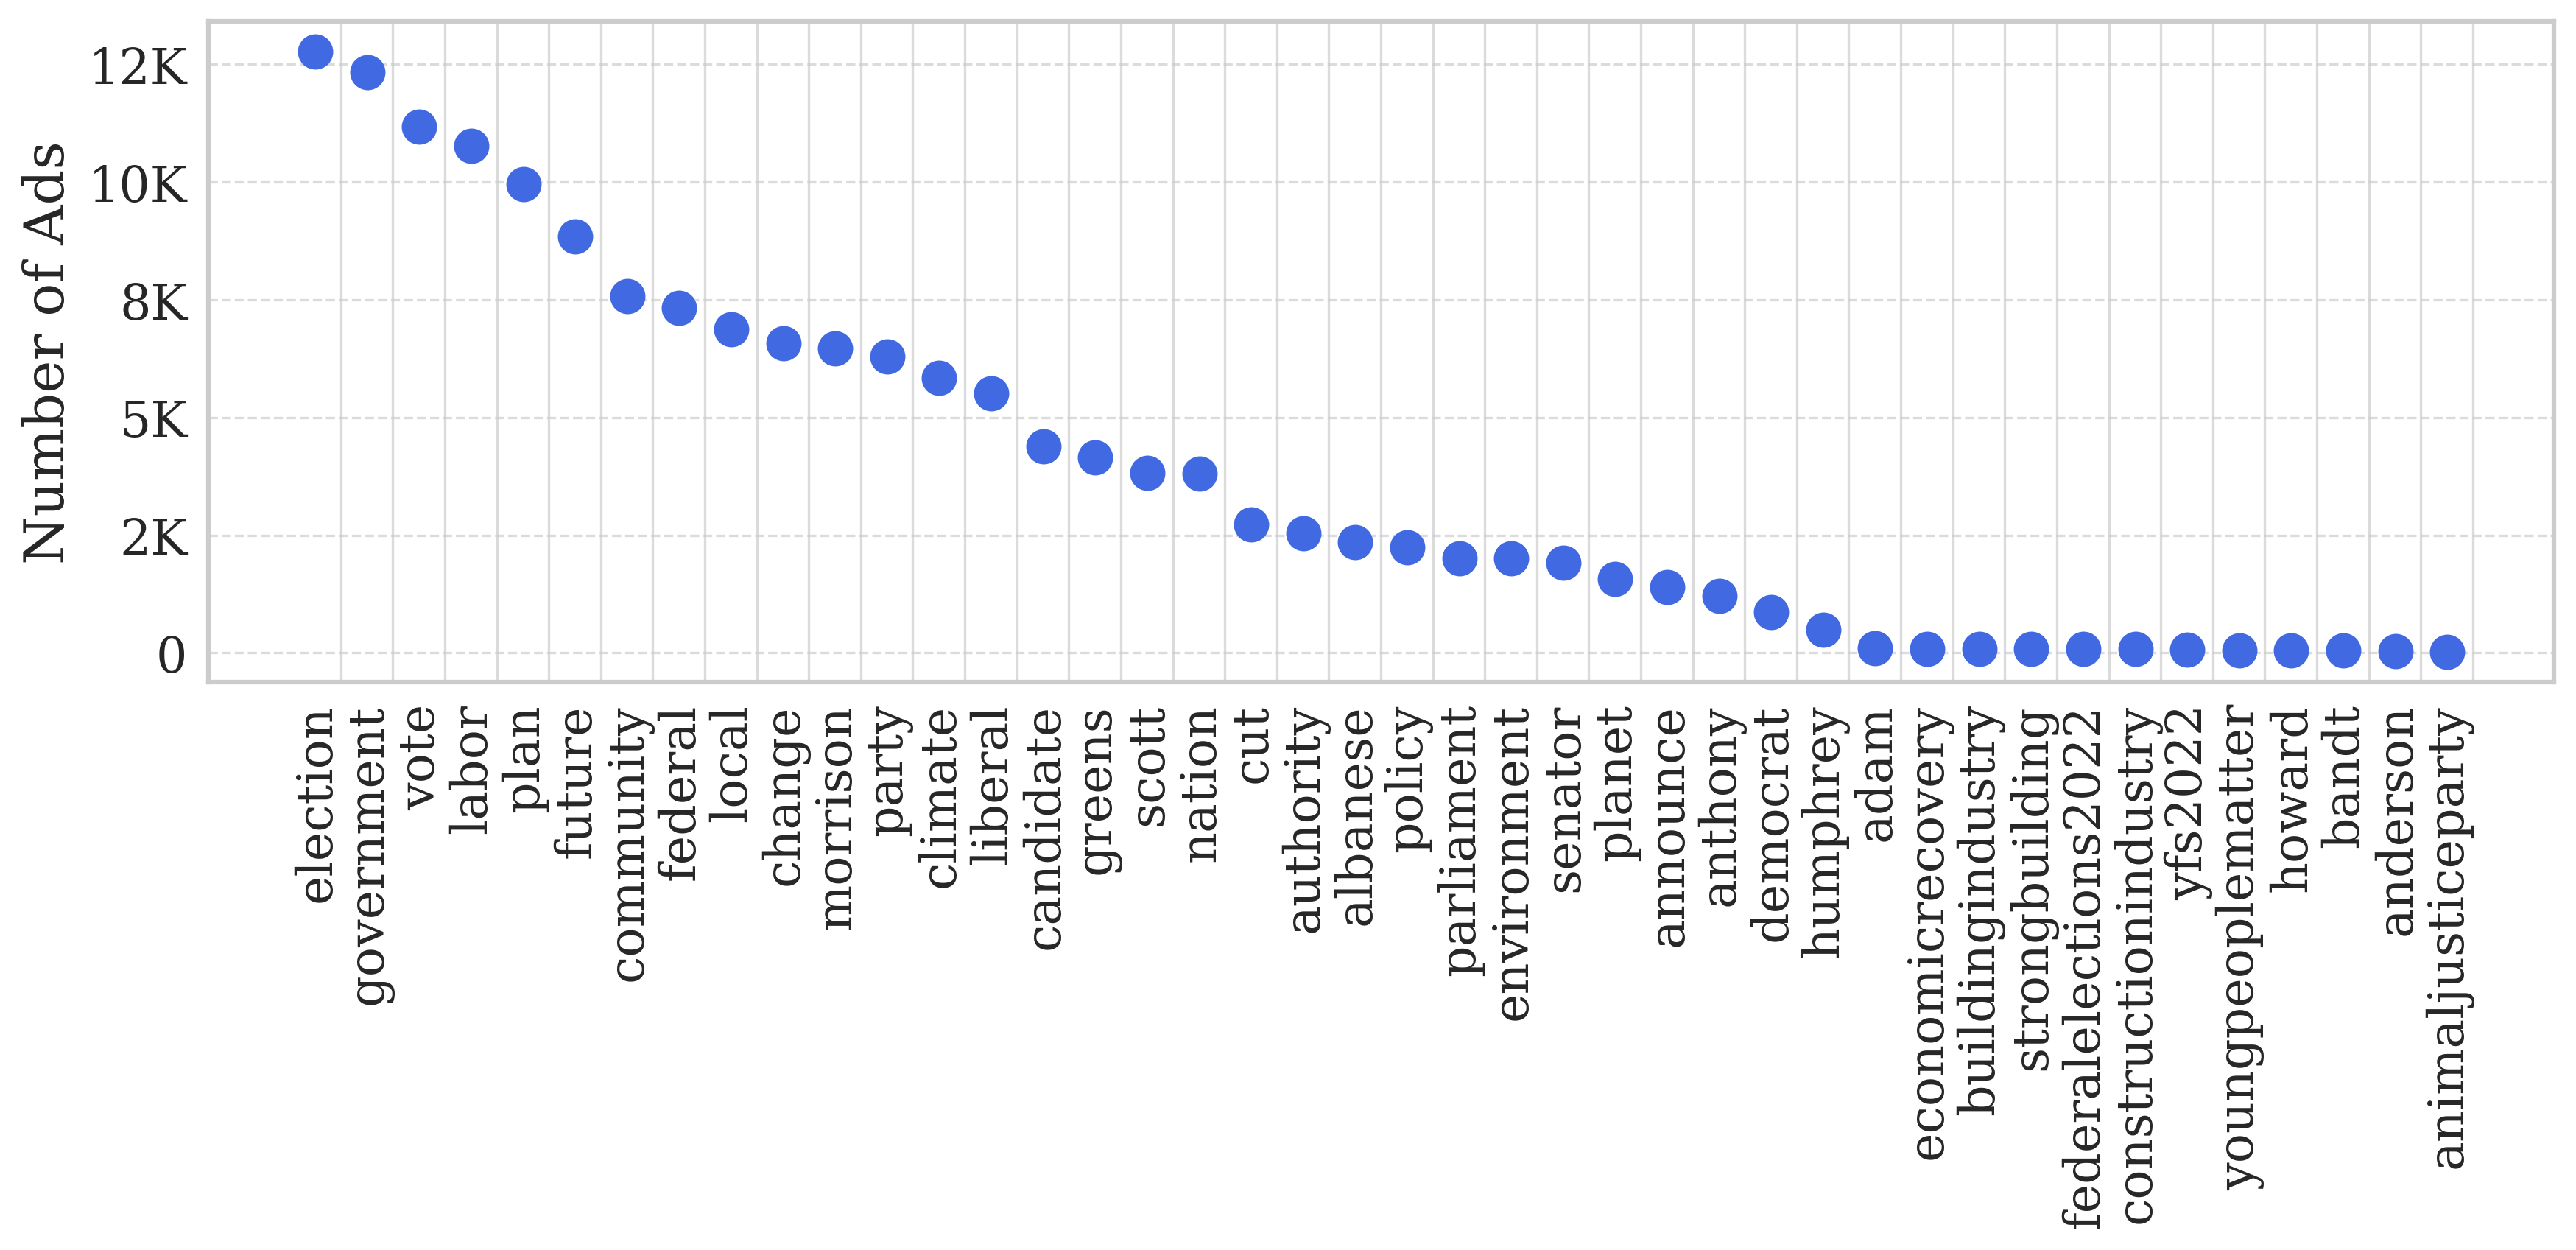

In [56]:
def create_keyword_dot_plot(keyword_counts, 
                            keywords_map,
                            figsize=(12, 6),
                            dot_size=100,
                            dot_color='royalblue',
                            axis_label_size=18,
                            tick_label_size=16,
                            ylabel='Number of Ads',
                            grid=False,
                            xtick_offset=0.49):
    
    def thousands_formatter(x, pos):
        return f'{x/1000:.0f}K' if x >= 1000 else f'{x:.0f}'

    # Sort the keyword counts
    sorted_keywords = sorted(keyword_counts.items(), key=lambda x: x[1], reverse=True)
    stemmed_keywords, counts = zip(*sorted_keywords)
    
    # Map stemmed keywords to original keywords
    original_keywords = [keywords_map.get(keyword, keyword) for keyword in stemmed_keywords]
    
    # Create the plot
    plt.figure(figsize=figsize)
    
    # Use range for x-coordinates to align dots with labels
    x = range(len(original_keywords))
    plt.scatter(x, counts, s=dot_size, color=dot_color, linewidth=1.5)
    
    # Set x-ticks and labels with original keywords
    plt.xticks([i + xtick_offset for i in x], original_keywords, rotation=90, ha='right')
    
    # Set labels and title
    plt.ylabel(ylabel, fontsize=axis_label_size)
    
    # Customize ticks
    plt.tick_params(axis='both', which='major', labelsize=tick_label_size)
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(thousands_formatter))
    
    # Add grid if specified
    plt.grid(grid, axis='y', linestyle='--', alpha=0.7)
    plt.grid(grid, axis='x', alpha=0.7)
    
    # Improve overall appearance
    plt.tight_layout()
    
    return plt

plt = create_keyword_dot_plot(keyword_counts, keywords_map)
plt.show()